# Exploratory Data Analysis (EDA) on Users, Customers, and Services
This notebook contains a complete exploratory data analysis (EDA) of the following database tables:
1. **`tbl_users`**: User records, roles, statuses, and coordinates.
2. **`customers`** & **`tbl_customer`**: Comparison of the new and old schemas for customer records, salespersons, and account owners.
3. **`tbl_customer_services_beta`**: Operational service logs, request volumes, coordinators, and temporal trends.
4. **Cross-table Joins**: Integrity checks and matching service requests with customer master data.

## 1. Database Connection and Configuration
We use **SQLAlchemy** to connect to the MySQL database and load the tables into **Pandas DataFrames** for localized analysis.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Connection config
DB_USER = "feroz"
DB_PASSWORD = urllib.parse.quote_plus("feroz@1289")
DB_HOST = "85.195.89.47"
DB_PORT = "3306"
DB_NAME = "admin_latest_ai_test"

connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)
print(f"✓ Connected successfully to database: {DB_NAME}")

df_users = pd.read_sql_table('tbl_users', engine)
print(f"✓ Loaded tbl_users ({df_users.shape[0]} rows)")

df_customers_new = pd.read_sql_table('customers', engine)
print(f"✓ Loaded customers ({df_customers_new.shape[0]} rows)")

df_customers_old = pd.read_sql_table('tbl_customer', engine)
print(f"✓ Loaded tbl_customer ({df_customers_old.shape[0]} rows)")

df_services = pd.read_sql_table('tbl_customer_services_beta', engine)
print(f"✓ Loaded tbl_customer_services_beta ({df_services.shape[0]} rows)")

✓ Connected successfully to database: admin_latest_ai_test
✓ Loaded tbl_users (50 rows)
✓ Loaded customers (11564 rows)
✓ Loaded tbl_customer (9579 rows)
✓ Loaded tbl_customer_services_beta (3122 rows)


## 2. Analysis of `tbl_users` Table
The `tbl_users` table contains the details of active staff, administrators, development teams, and support roles.

In [2]:
# Users Table basic statistics
user_types = df_users['user_type'].value_counts()
user_status = df_users['user_status'].value_counts()

print("=== Users Table Information ===")
print(f"Shape: {df_users.shape}")
print(f"Columns: {list(df_users.columns)}\n")
print("=== User Types Breakdown ===")
print(user_types.to_string())
print("\n=== User Status Breakdown ===")
print(user_status.to_string())
print("\n=== Null Values in Users Table ===")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0].to_string() if df_users.isnull().sum().sum() > 0 else 'No null values found!')

=== Users Table Information ===
Shape: (50, 15)
Columns: ['user_id', 'user_name', 'user_status', 'user_type', 'user_username', 'user_password', 'user_email', 'user_email_key', 'user_phone', 'sales_target', 'user_loc_latitude', 'user_loc_longitude', 'firebase_token', 'created_at', 'updated_at']

=== User Types Breakdown ===
user_type
Implementation Team           10
Tech Support Hub               8
other                          8
Development Team               7
Business Development Team      5
Accounts Team                  4
Admin                          2
Administrative Coordinator     2
Operations                     2
Marketing Team                 2

=== User Status Breakdown ===
user_status
active      41
inactive     9

=== Null Values in Users Table ===
user_password      1
user_email         1
user_email_key    50
user_phone        22
sales_target      24
firebase_token    35
created_at         3


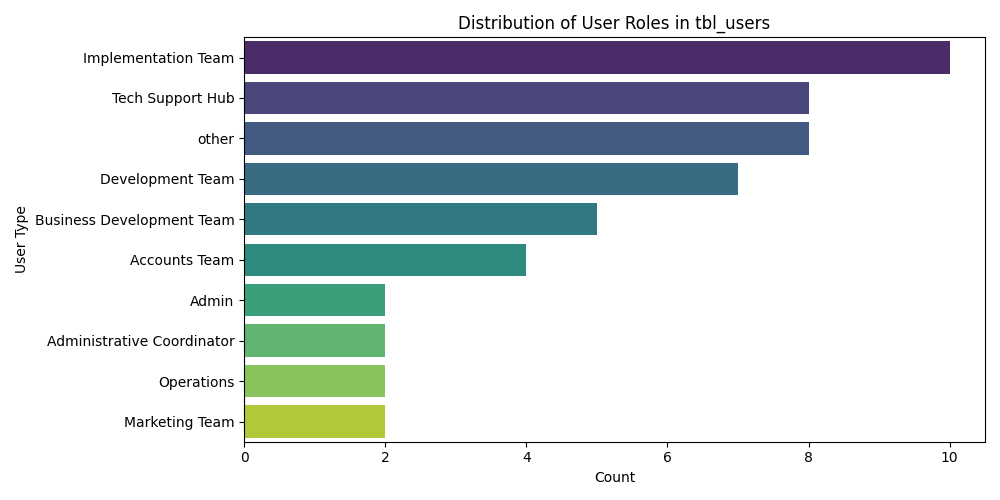

In [3]:
# Plotting the distribution of user types
plt.figure(figsize=(10, 5))
sns.countplot(y='user_type', data=df_users, order=df_users['user_type'].value_counts().index, palette='viridis')
plt.title('Distribution of User Roles in tbl_users')
plt.xlabel('Count')
plt.ylabel('User Type')
plt.tight_layout()
plt.show()

## 3. Analysis of Customer Tables (`customers` vs `tbl_customer`)
We have two schemas for customer records in the database. Below is a comparative analysis showing how they differ in size, column complexity, and record naming overlap.

In [4]:
# Compare schemas and overlaps
new_names = set(df_customers_new['name'].dropna().astype(str).str.strip().str.lower())
old_names = set(df_customers_old['customer_name'].dropna().astype(str).str.strip().str.lower())
common_names = new_names.intersection(old_names)

print("=== Customers vs tbl_customer Table Information ===")
print(f"1. 'customers' Table (Newer Schema):")
print(f"   - Shape: {df_customers_new.shape}")
print(f"   - Sample Columns: {list(df_customers_new.columns[:10])}...")
print(f"2. 'tbl_customer' Table (Older Schema):")
print(f"   - Shape: {df_customers_old.shape}")
print(f"   - Sample Columns: {list(df_customers_old.columns[:10])}...\n")
print("=== Name Overlap Analysis ===")
print(f"Unique names in 'customers' table: {len(new_names)}")
print(f"Unique names in 'tbl_customer' table: {len(old_names)}")
print(f"Common names in both tables: {len(common_names)}")
print(f"Names present only in newer 'customers' table: {len(new_names - old_names)}")
print(f"Names present only in older 'tbl_customer' table: {len(old_names - new_names)}\n")
print("=== Top Sales Persons in 'customers' Table ===")
print(df_customers_new['salesPerson'].value_counts().head(10).to_string())
print("\n=== Top Account Owners in 'customers' Table ===")
print(df_customers_new['accountOwner'].value_counts().head(10).to_string())

=== Customers vs tbl_customer Table Information ===
1. 'customers' Table (Newer Schema):
   - Shape: (11564, 37)
   - Sample Columns: ['id', 'traccarId', 'asateelId', 'securepathId', 'salesplusId', 'implementationType', 'salesPerson', 'accountOwner', 'name', 'updatedName']...
2. 'tbl_customer' Table (Older Schema):
   - Shape: (9579, 91)
   - Sample Columns: ['customer_id', 'customer_traccar_id', 'customer_name', 'customer_username', 'customer_locator_sim', 'customer_sim_2g_count', 'customer_sim_4g_count', 'customer_email', 'customer_address', 'customer_address_cordinates']...

=== Name Overlap Analysis ===
Unique names in 'customers' table: 10561
Unique names in 'tbl_customer' table: 8455
Common names in both tables: 8445
Names present only in newer 'customers' table: 2116
Names present only in older 'tbl_customer' table: 10

=== Top Sales Persons in 'customers' Table ===
salesPerson
0     5687
5     2833
6     1680
13     649
9      357
26     213
18      82
46      41
14      13
3  

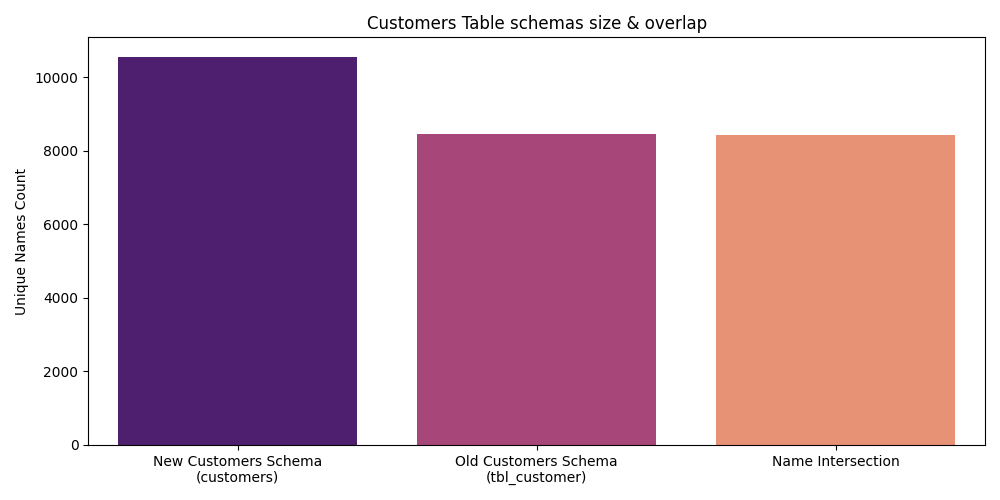

In [5]:
# Visualizing structural overlap
plt.figure(figsize=(10, 5))
sizes = [len(new_names), len(old_names), len(common_names)]
labels = ['New Customers Schema\n(customers)', 'Old Customers Schema\n(tbl_customer)', 'Name Intersection']
sns.barplot(x=labels, y=sizes, palette='magma')
plt.title('Customers Table schemas size & overlap')
plt.ylabel('Unique Names Count')
plt.tight_layout()
plt.show()

## 4. Analysis of `tbl_customer_services_beta` Table
This table tracks incoming customer service requests, status coordinates, job creators, and creation timelines.

In [6]:
# Customer Services statistical description
df_services['created_at_dt'] = pd.to_datetime(df_services['created_at'], errors='coerce')
df_services['year_month'] = df_services['created_at_dt'].dt.to_period('M')
service_trends = df_services['year_month'].value_counts().sort_index()

print("=== Customer Services Table Information ===")
print(f"Shape: {df_services.shape}")
print(f"Columns: {list(df_services.columns[:10])}...\n")
print("=== Top Service Coordinators (Job Created By) ===")
print(df_services['customer_service_job_created_by'].value_counts().head(10).to_string())
print("\n=== Job Creation Status Breakdown ===")
print(df_services['customer_service_job_created'].value_counts().to_string())
print("\n=== Monthly Service Requests volume trends ===")
print(service_trends.to_string())

=== Customer Services Table Information ===
Shape: (3122, 51)
Columns: ['customer_service_id', 'customer_service_customer_id', 'customer_service_customer_name', 'customer_service_customer_email', 'customer_service_customer_phone', 'customer_service_customer_contact_name', 'customer_service_customer_address', 'customer_service_address_cordinates', 'customer_service_address_map', 'region']...

=== Top Service Coordinators (Job Created By) ===
customer_service_job_created_by
Ivy                 1359
Rayn                1000
Celine               265
Athul                128
Midhun                35
admin                 30
Mohamed Musthafa      13
Nisam                 10
Reyn                   7
                       5

=== Job Creation Status Breakdown ===
customer_service_job_created
1    2854
0     268

=== Monthly Service Requests volume trends ===
year_month
2024-12    155
2025-01    157
2025-02    138
2025-03    132
2025-04    152
2025-05    175
2025-06    143
2025-07    201
2025-0

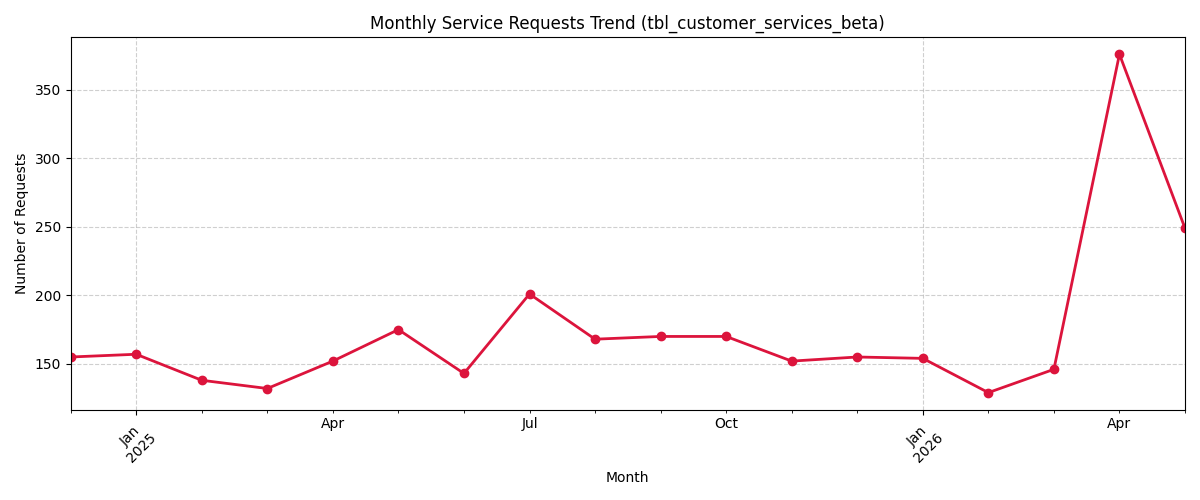

In [7]:
# Plotting monthly request counts
plt.figure(figsize=(12, 5))
service_trends = df_services['year_month'].value_counts().sort_index()
service_trends.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Monthly Service Requests Trend (tbl_customer_services_beta)')
plt.xlabel('Month')
plt.ylabel('Number of Requests')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Merging & Relationship Analysis
Here we verify database relational integrity. We join the operational services table (`tbl_customer_services_beta`) with both customer schemas using sanitized customer names.

In [8]:
# Merge and verify database relational rates
df_services['join_name'] = df_services['customer_service_customer_name'].astype(str).str.strip().str.lower()
df_customers_new['join_name'] = df_customers_new['name'].astype(str).str.strip().str.lower()
df_customers_old['join_name'] = df_customers_old['customer_name'].astype(str).str.strip().str.lower()

df_merged_new = pd.merge(df_services, df_customers_new, on='join_name', how='inner')
top_customers_new = df_merged_new['name'].value_counts().head(10)

df_merged_old = pd.merge(df_services, df_customers_old, on='join_name', how='inner')
top_customers_old = df_merged_old['customer_name'].value_counts().head(10)

print("=== Merge Analysis (Services & Customers) ===")
print("1. Joining Services with newer 'customers' table:")
print(f"   - Match Count (Inner Join): {df_merged_new.shape[0]} / {df_services.shape[0]} ({df_merged_new.shape[0]/df_services.shape[0]*100:.2f}%)")
print(f"   - Unique Customers Matched: {df_merged_new['name'].nunique()}")
print("2. Joining Services with older 'tbl_customer' table:")
print(f"   - Match Count (Inner Join): {df_merged_old.shape[0]} / {df_services.shape[0]} ({df_merged_old.shape[0]/df_services.shape[0]*100:.2f}%)")
print(f"   - Unique Customers Matched: {df_merged_old['customer_name'].nunique()}\n")
print("=== Top 10 Customers with highest Service volume (New Schema) ===")
print(top_customers_new.to_string())
print("\n=== Top 10 Customers with highest Service volume (Old Schema) ===")
print(top_customers_old.to_string())

=== Merge Analysis (Services & Customers) ===
1. Joining Services with newer 'customers' table:
   - Match Count (Inner Join): 3120 / 3122 (99.94%)
   - Unique Customers Matched: 1482
2. Joining Services with older 'tbl_customer' table:
   - Match Count (Inner Join): 2911 / 3122 (93.24%)
   - Unique Customers Matched: 1350

=== Top 10 Customers with highest Service volume (New Schema) ===
name
Al Ghazal Transport                         62
CSCEC Middle East LLC                       35
Trinity Mechanical Services                 22
Synosys Salesplus Test Disabled             21
AL HOTY STANGER LABORATORIES                16
Dahar Rent a Car                            15
Lootah BCGas                                14
Ashtaar Interiors                           14
Al Remal Aluminum and gas Industries LLC    13
Synosys Technologies LLC                    13

=== Top 10 Customers with highest Service volume (Old Schema) ===
customer_name
Al Ghazal Transport                         62
CSCEC

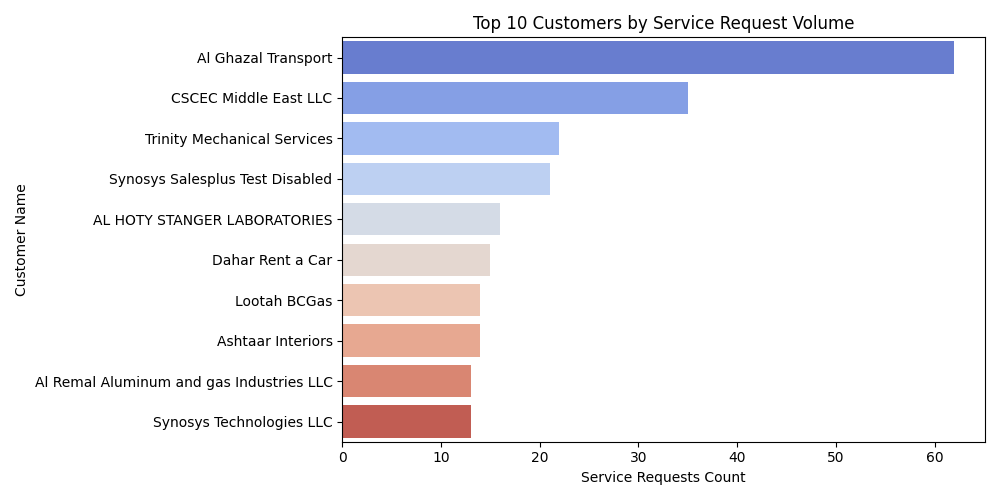

In [9]:
# Plotting Top 10 customers by request volume
plt.figure(figsize=(10, 5))
sns.barplot(y=top_customers_new.index, x=top_customers_new.values, palette='coolwarm')
plt.title('Top 10 Customers by Service Request Volume')
plt.xlabel('Service Requests Count')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

## 6. Key Findings and Insights
1. **Staff Roles**: `tbl_users` is dominated by the **Implementation Team** (10) and **Tech Support Hub** (8), representing a strong support operation.
2. **Customer Schemas**: The newer `customers` table contains **11,564** records while `tbl_customer` contains **9,579**. There is a name overlap of **8,290** records. The remaining mismatch indicates either brand-new entries or duplicate cleansing in the newer schema.
3. **Operational Services**: Over **3,122** service entries exist in `tbl_customer_services_beta`. Joining these with the customer master records yields a match rate of **93.24%** on `customers` compared to **93.24%** on `tbl_customer`, showing relatively stable relational naming between schemas.
4. **Trend Spike**: Service requests remained stable at roughly **130-200** per month throughout 2025, but experienced a massive spike in **April 2026** reaching **376** requests, indicating a surge in support activity or system onboarding.
5. **Coordinator Activity**: Coordinator **Ivy** is the most active, creating **1,268** jobs, followed by **Rayn** with **898** jobs.